In [1]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import os
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set_style("whitegrid")
from model import *
from noise import *
from torch.utils.data import DataLoader, Dataset

torch.set_default_dtype(torch.float64)

from math import *
import copy
from scipy.integrate import odeint
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import random
from mpl_toolkits.mplot3d import Axes3D
from math import *
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import matplotlib.pyplot as plt
from numpy import exp,arange
from pylab import meshgrid,cm,imshow,contour,clabel,colorbar,axis,title,show
#device = torch.device("cuda:0")
dtype = torch.float

## Read Data and Process Data

In [2]:
#Read data from .csv file
approx_sol = pd.read_csv('eg2_sol.csv', sep=',')
approx_solut = approx_sol.to_numpy()

#Data properties
components = 1 #spatial dimensions
deltat = 0.04
t = np.arange(0, 1, deltat)
time_steps = len(t)
n_initial_cond = approx_solut.shape[0] #number of initial conditions for solutions

#Read True RHS from .csv file
true_der = pd.read_csv('eg2_true_RHS.csv', sep=',')
true_der = true_der.to_numpy()

#Read Difference Quotients from .csv file
Diff_quot = pd.read_csv('eg2_app_RHS.csv', sep=',')
Diff_quot = Diff_quot.to_numpy()

In [3]:
# Add noise
approx_solut_noise, DQ_noise = add_noise(approx_solut, t, deltat, 0.1)

In [6]:
approx_solut_noise.shape, DQ_noise.shape

((200, 95), (200, 97))

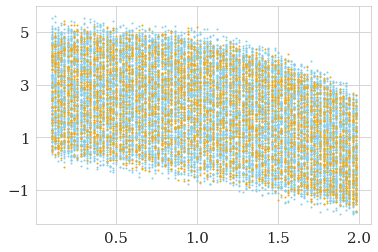

In [8]:
# Append t and x(t)
t_copy = np.tile(t, n_initial_cond).reshape(-1,1)
x_t = approx_solut_noise.reshape(-1,1) 
inputs = np.append(t_copy, x_t, axis=1)
targets = DQ_noise[:,1:-1].reshape(-1,1)

# train-test split 
X_train, X_test, Y_train, Y_test = train_test_split(inputs, targets, test_size=0.2)

# visualization
fontsize=15
plt.scatter(X_train[:,0], X_train[:,1], color='skyblue', s=1)
plt.scatter(X_test[:,0], X_test[:,1], color='orange', s=1)
plt.xticks([0,1], size = fontsize, fontname = 'serif')
plt.yticks([-1,1], size = fontsize, fontname = 'serif')
plt.show()

In [9]:
#Define LoadDataset
class LoadDataset(Dataset):
    def __init__(self, inputs, targets):
        self.x = inputs
        self.y = targets

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        inputs = self.x[idx, :]
        targets = self.y[idx, :]

        return inputs, targets

## Define Random Features

In [10]:
n = 100 #grid points where we do the recovery

# Define real RHS
def z_func(t,x):
    return np.log(t) * np.exp(-x) - t ** 2

#define recovery domain boundaries
x_low = 0
x_top = 5
t_low = 0.1
t_top = 2.

#generate grid of x and t in the recovery domain
x = np.linspace(x_low, x_top, n)
time1 = np.linspace(t_low, t_top, n)
T,X = np.meshgrid(time1,x)

#compute true RHS on grid
Z = z_func(T, X)

#Generate input for netowrk
new_X = X.reshape(-1,1)
new_T = T.reshape(-1,1)
X_new = np.append(new_T,new_X,axis = 1)

Best error is 8.40e-03


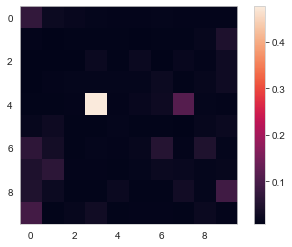

In [11]:
# Setup Parameters
N_range = range(10,110,10)      # number of features
sigma_range = range(1,11)  # variance parameter
T = 10                          # repeat T times
reg_param = 0                # fixed regularization parameter

# record errors
train_errors = np.zeros((T, len(N_range), len(sigma_range)))
test_errors = np.zeros((T, len(N_range), len(sigma_range)))
non_rel_errors = np.zeros((T, len(N_range), len(sigma_range)))

for t in range(T):
    
    for i in range(len(N_range)):
        
        N = N_range[i]
        
        for j in range(len(sigma_range)):
            
            sigma = sigma_range[j]
            W = np.random.randn(2,N) / sigma
            b = np.random.uniform(0, 2*np.pi, size=(N,))
            A = np.cos(X_train @ W + b) * np.sqrt(2/N)
            c = np.linalg.solve(A.T@A + reg_param * np.linalg.norm(W,axis=0), A.T@Y_train)

            # training loss
            train_errors[t,i,j] = np.mean((A @ c - Y_train)**2)

            # test loss
            A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
            test_errors[t,i,j] = np.mean((A_test @ c - Y_test)**2)

            # non-trajectory data relative errors
            A_non = np.cos(X_new @ W + b) * np.sqrt(2/N)
            Z_RF = A_non @ c
            Z_RF = Z_RF.reshape(n,n)
            non_rel_errors[t,i,j] = np.mean(abs(Z - Z_RF))/(np.abs(np.max(Z)-np.min(Z)))
            
plt.imshow( np.mean(non_rel_errors, axis=0) )
plt.grid()
plt.colorbar()

a = np.min(np.mean(non_rel_errors, axis=0))
print('Best error is {:.2e}'.format(a))

Best error is 8.52e-03


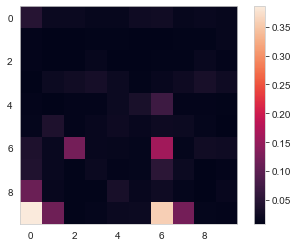

In [12]:
# Setup Parameters
N_range = range(10,110,10)      # number of features
sigma_range = range(1,11)  # variance parameter
T = 10                          # repeat T times
reg_param = 0.001                # fixed regularization parameter

# record errors
train_errors = np.zeros((T, len(N_range), len(sigma_range)))
test_errors = np.zeros((T, len(N_range), len(sigma_range)))
non_rel_errors = np.zeros((T, len(N_range), len(sigma_range)))

for t in range(T):
    
    for i in range(len(N_range)):
        
        N = N_range[i]
        
        for j in range(len(sigma_range)):
            
            sigma = sigma_range[j]
            W = np.random.randn(2,N) / sigma
            b = np.random.uniform(0, 2*np.pi, size=(N,))
            A = np.cos(X_train @ W + b) * np.sqrt(2/N)
            c = np.linalg.solve(A.T@A + reg_param * np.linalg.norm(W,axis=0), A.T@Y_train)

            # training loss
            train_errors[t,i,j] = np.mean((A @ c - Y_train)**2)

            # test loss
            A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
            test_errors[t,i,j] = np.mean((A_test @ c - Y_test)**2)

            # non-trajectory data relative errors
            A_non = np.cos(X_new @ W + b) * np.sqrt(2/N)
            Z_RF = A_non @ c
            Z_RF = Z_RF.reshape(n,n)
            non_rel_errors[t,i,j] = np.mean(abs(Z - Z_RF))/(np.abs(np.max(Z)-np.min(Z)))
            
plt.imshow( np.mean(non_rel_errors, axis=0) )
plt.grid()
plt.colorbar()

a = np.min(np.mean(non_rel_errors, axis=0))
print('Best error is {:.2e}'.format(a))

Best error is 8.08e-03


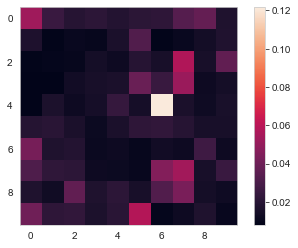

In [13]:
# Setup Parameters
N_range = range(10,110,10)      # number of features
sigma_range = range(1,11)  # variance parameter
T = 10                          # repeat T times
reg_param = 0.01               # fixed regularization parameter

# record errors
train_errors = np.zeros((T, len(N_range), len(sigma_range)))
test_errors = np.zeros((T, len(N_range), len(sigma_range)))
non_rel_errors = np.zeros((T, len(N_range), len(sigma_range)))

for t in range(T):
    
    for i in range(len(N_range)):
        
        N = N_range[i]
        
        for j in range(len(sigma_range)):
            
            sigma = sigma_range[j]
            W = np.random.randn(2,N) / sigma
            b = np.random.uniform(0, 2*np.pi, size=(N,))
            A = np.cos(X_train @ W + b) * np.sqrt(2/N)
            c = np.linalg.solve(A.T@A + reg_param * np.linalg.norm(W,axis=0), A.T@Y_train)

            # training loss
            train_errors[t,i,j] = np.mean((A @ c - Y_train)**2)

            # test loss
            A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
            test_errors[t,i,j] = np.mean((A_test @ c - Y_test)**2)

            # non-trajectory data relative errors
            A_non = np.cos(X_new @ W + b) * np.sqrt(2/N)
            Z_RF = A_non @ c
            Z_RF = Z_RF.reshape(n,n)
            non_rel_errors[t,i,j] = np.mean(abs(Z - Z_RF))/(np.abs(np.max(Z)-np.min(Z)))
            
plt.imshow( np.mean(non_rel_errors, axis=0) )
plt.grid()
plt.colorbar()

a = np.min(np.mean(non_rel_errors, axis=0))
print('Best error is {:.2e}'.format(a))

Best error is 7.75e-03


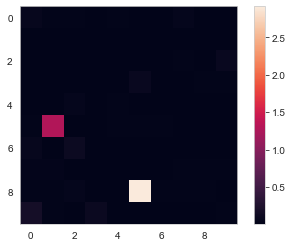

In [14]:
# Setup Parameters
N_range = range(10,110,10)      # number of features
sigma_range = range(1,11)  # variance parameter
T = 10                          # repeat T times
reg_param = 0.1                # fixed regularization parameter

# record errors
train_errors = np.zeros((T, len(N_range), len(sigma_range)))
test_errors = np.zeros((T, len(N_range), len(sigma_range)))
non_rel_errors = np.zeros((T, len(N_range), len(sigma_range)))

for t in range(T):
    
    for i in range(len(N_range)):
        
        N = N_range[i]
        
        for j in range(len(sigma_range)):
            
            sigma = sigma_range[j]
            W = np.random.randn(2,N) / sigma
            b = np.random.uniform(0, 2*np.pi, size=(N,))
            A = np.cos(X_train @ W + b) * np.sqrt(2/N)
            c = np.linalg.solve(A.T@A + reg_param * np.linalg.norm(W,axis=0), A.T@Y_train)

            # training loss
            train_errors[t,i,j] = np.mean((A @ c - Y_train)**2)

            # test loss
            A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
            test_errors[t,i,j] = np.mean((A_test @ c - Y_test)**2)

            # non-trajectory data relative errors
            A_non = np.cos(X_new @ W + b) * np.sqrt(2/N)
            Z_RF = A_non @ c
            Z_RF = Z_RF.reshape(n,n)
            non_rel_errors[t,i,j] = np.mean(abs(Z - Z_RF))/(np.abs(np.max(Z)-np.min(Z)))
            
plt.imshow( np.mean(non_rel_errors, axis=0) )
plt.grid()
plt.colorbar()

a = np.min(np.mean(non_rel_errors, axis=0))
print('Best error is {:.2e}'.format(a))